# Import Libraries

In [122]:
import pandas as pd
import geopandas as gpd
import numpy as np
import ast
import statsmodels.api as sm
import re
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

pio.renderers.default = "vscode"
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, HalvingGridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report , roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

# Data Collection

In [16]:
dataset = gpd.read_file("data/Processed/model_prep_data.geojson")


# Data Processing

In [17]:
def clean_speed(val):

    if val is None:
        return np.nan

    val = str(val)
    nums = re.findall(r'\d+', val)

    if not nums:
        return np.nan

    nums = [int(n) for n in nums]

    return max(nums)


dataset["speed_limit"] = dataset["maxspeed"].apply(clean_speed)

In [18]:
dataset["speed_limit"] = dataset["speed_limit"].clip(lower=10)

In [19]:
edges = dataset[dataset['dist_to_station'] < 7000]

edges=edges.to_crs("EPSG:4326")

edges = edges[['geometry','length_m','speed_limit','dist_to_intersection',
       'oneway','lanes','is_bike_network','bike_network_type',
       'dist_to_bike_network','near_bike_lane','crash_count','crash',
       'grid_road_length','grid_bike_length','grid_intersections',
       'road_class','bike_flow','bike_flow_log']].copy()

edges.dropna(inplace=True)

edges.to_file("data/Processed/prepared_model_data.geojson", driver="GeoJSON")

In [20]:
edges

,geometry,length_m,speed_limit,dist_to_intersection,oneway,lanes,is_bike_network,bike_network_type,dist_to_bike_network,near_bike_lane,crash_count,crash,grid_road_length,grid_bike_length,grid_intersections,road_class,bike_flow,bike_flow_log
0,"LINESTRING (13.3355 52.56521, 13.3354 52.56516...",437.787811,50.0,155.882766,0,1.0,1,Ergänzungsnetz,0.000000,1,0.0,0,827.188992,320.166724,1.0,secondary,377.428765,5.936028
1,"LINESTRING (13.3355 52.56521, 13.3356 52.56526...",689.267903,50.0,142.313317,0,2.0,1,Radvorrangnetz,0.000000,1,0.0,0,468.753416,234.482834,0.0,secondary,369.265926,5.914221
2,"LINESTRING (13.3355 52.56521, 13.33557 52.5651...",241.575024,50.0,117.807506,0,2.0,1,Radvorrangnetz,0.000000,1,0.0,0,1002.858841,27.776110,2.0,tertiary,331.975734,5.808070
3,"LINESTRING (13.34661 52.56703, 13.34664 52.56688)",17.188043,50.0,8.594021,0,1.0,1,Radvorrangnetz,0.000000,1,0.0,0,959.917063,390.006322,4.0,tertiary,459.304898,6.131889
4,"LINESTRING (13.34661 52.56703, 13.3465 52.5670...",103.460404,50.0,50.592958,1,2.0,1,Radvorrangnetz,0.000000,1,0.0,0,959.917063,390.006322,4.0,secondary,455.278171,6.123103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73775,"LINESTRING (13.50746 52.49189, 13.50755 52.492...",73.014091,30.0,36.506478,0,1.0,1,Ergänzungsnetz,0.049245,1,0.0,0,1259.818866,508.513475,5.0,residential,627.872577,6.443929
73776,"LINESTRING (13.50756 52.49177, 13.50777 52.491...",111.625834,30.0,55.812911,0,1.0,1,Radvorrangnetz,0.000000,1,0.0,0,659.561583,330.953738,0.0,residential,517.081232,6.250132
73794,"LINESTRING (13.27533 52.42229, 13.27533 52.42228)",1.478276,50.0,0.739138,0,2.0,1,Radvorrangnetz,0.688967,1,0.0,0,1997.980782,256.485257,15.0,secondary,158.856816,5.074279
73796,"LINESTRING (13.27533 52.42229, 13.27536 52.422...",42.745706,50.0,21.372851,0,2.0,1,Radvorrangnetz,0.000000,1,0.0,0,1997.980782,256.485257,15.0,secondary,159.338050,5.077284


In [21]:
edges['crash'].value_counts()

crash
0    56862
1     4122
Name: count, dtype: int64

# Feature Engineering

In [22]:
edges["bike_ratio"] = edges["grid_bike_length"] / edges["grid_road_length"]
edges["bike_ratio"] = edges["bike_ratio"].fillna(0)

edges['road_density'] = edges['grid_road_length'] / (250 * 250)

edges['intersection_density'] = edges['grid_intersections'] / (edges['grid_road_length'] + 1)

In [23]:
features = [

'length_m',
'speed_limit',
'dist_to_intersection',
'oneway',
'lanes',

'is_bike_network',
'bike_network_type',
'dist_to_bike_network',
'near_bike_lane',

'grid_road_length',
'grid_bike_length',
'bike_ratio',

'road_density',
'road_class',
'bike_flow_log'

]

y = edges["crash"]
X = edges[features]

X = pd.get_dummies(X, drop_first=True)

X = X.fillna(0)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model Training

In [25]:
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train, y_train)

pred_log = log_model.predict_proba(X_test)[:,1]

print("\nLOGISTIC REGRESSION PERFORMANCE")
print("ROC AUC:", roc_auc_score(y_test, pred_log))
print(classification_report(y_test, log_model.predict(X_test)))


LOGISTIC REGRESSION PERFORMANCE
ROC AUC: 0.7990034415525102
              precision    recall  f1-score   support

           0       0.98      0.71      0.82     11373
           1       0.16      0.75      0.26       824

    accuracy                           0.71     12197
   macro avg       0.57      0.73      0.54     12197
weighted avg       0.92      0.71      0.78     12197



In [ ]:
# rf_params = {
#     "n_estimators": [550,600,650],
#     "max_depth": [10,12,14,None],
#     "min_samples_split": [12,13,15],
#     "min_samples_leaf": [9,10,11]
# }


# rf_grid = HalvingGridSearchCV(
#    RandomForestClassifier(random_state=10,class_weight="balanced"),
#     rf_params,
#     cv=5,
#     factor=3,
#     scoring="roc_auc",
#     n_jobs=-1)

# rf_grid.fit(X_train, y_train)

# best_rf = rf_grid.best_estimator_

# print("Best Random Forest params:", rf_grid.best_params_)

Best Random Forest params: {'n_estimators': 550, 'max_depth': 12, 'min_samples_split': 12, 'min_samples_leaf': 10}


In [114]:
rf = RandomForestClassifier(
    n_estimators=550,
    class_weight="balanced",
    max_depth=12,
    min_samples_split=12,
    min_samples_leaf=10)

rf.fit(X_train, y_train)

pred_rf = rf.predict_proba(X_test)[:,1]

print("\nRANDOM FOREST PERFORMANCE")
print("ROC AUC:", roc_auc_score(y_test, pred_rf))
print(classification_report(y_test, rf.predict(X_test)))

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance.head(15)


RANDOM FOREST PERFORMANCE
ROC AUC: 0.8451187192627061
              precision    recall  f1-score   support

           0       0.97      0.85      0.91     11373
           1       0.24      0.66      0.35       824

    accuracy                           0.84     12197
   macro avg       0.61      0.75      0.63     12197
weighted avg       0.92      0.84      0.87     12197



bike_flow_log             0.224527
length_m                  0.113147
dist_to_intersection      0.100695
road_class_residential    0.079162
dist_to_bike_network      0.076593
bike_ratio                0.060261
grid_road_length          0.059874
road_density              0.059403
grid_bike_length          0.054820
speed_limit               0.041551
lanes                     0.027195
near_bike_lane            0.022739
road_class_secondary      0.018139
bike_network_type_none    0.014402
is_bike_network           0.011635
dtype: float64

In [ ]:
# xgb_params = {
#     "n_estimators": [400,500,600],
#     "max_depth": [7,8,10],
#     "learning_rate": [0.01,0.05,0.1],
#     "subsample": [0.8,1],
#     "colsample_bytree": [0.8,1]}

# xgb_grid = HalvingGridSearchCV(
#     XGBClassifier(eval_metric="logloss", random_state=42 ,scale_pos_weight= 5),
#     xgb_params,
#     cv=5,
#     factor=3,
#     scoring="roc_auc",
#     n_jobs=-1)

# xgb_grid.fit(X_train, y_train)

# best_xgb = xgb_grid.best_estimator_

# print("Best XGBoost params:", {"n_estimators": 500,"max_depth": 8,"learning_rate": 0.05,"subsample": 0.8, "colsample_bytree": 0.8})

Best XGBoost params: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}


In [117]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=5,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict_proba(X_test)[:,1]

print("\nXGBOOST PERFORMANCE")
print("ROC AUC:", roc_auc_score(y_test, pred_xgb))
print(classification_report(y_test, xgb.predict(X_test)))

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_importance.head(15)


XGBOOST PERFORMANCE
ROC AUC: 0.8613004825771138
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     11373
           1       0.48      0.46      0.47       824

    accuracy                           0.93     12197
   macro avg       0.72      0.71      0.72     12197
weighted avg       0.93      0.93      0.93     12197



road_class_residential    0.207060
road_class_other          0.096623
near_bike_lane            0.081746
bike_flow_log             0.059981
speed_limit               0.055127
road_class_secondary      0.042328
bike_network_type_none    0.040901
length_m                  0.038943
road_density              0.038405
dist_to_bike_network      0.037544
dist_to_intersection      0.037460
bike_ratio                0.036585
is_bike_network           0.036106
grid_bike_length          0.034985
grid_road_length          0.034592
dtype: float32

# Model Results

In [124]:
y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr_log,
    y=tpr_log,
    mode='lines',
    name=f'Logistic Regression (AUC = {auc_log:.3f})'
))

fig.add_trace(go.Scatter(
    x=fpr_rf,
    y=tpr_rf,
    mode='lines',
    name=f'Random Forest (AUC = {auc_rf:.3f})'
))

fig.add_trace(go.Scatter(
    x=fpr_xgb,
    y=tpr_xgb,
    mode='lines',
    name=f'XGBoost (AUC = {auc_xgb:.3f})'
))

fig.add_trace(go.Scatter(
    x=[0,1],
    y=[0,1],
    mode='lines',
    line=dict(dash='dash'),
    name='Random Classifier'
))

fig.update_layout(
    title="ROC Curve Comparison",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    width=800,
    height=600
)

fig.show()

In [ ]:
coef = pd.Series(log_model.coef_[0], index=X.columns)

odds_ratio = np.exp(coef)

or_table = pd.DataFrame({
    "coefficient": coef,
    "odds_ratio": odds_ratio,
    "percent_change_odds": (odds_ratio - 1) * 100
}).sort_values("odds_ratio")

print("\nLOGISTIC REGRESSION ODDS RATIOS")
print(or_table.round(3))



LOGISTIC REGRESSION ODDS RATIOS
                                  coefficient  odds_ratio  percent_change_odds
road_class_other                       -1.972       0.139              -86.084
is_bike_network                        -1.852       0.157              -84.307
road_class_residential                 -1.475       0.229              -77.130
bike_network_type_none                 -0.671       0.511              -48.896
road_class_tertiary                    -0.665       0.514              -48.585
bike_ratio                             -0.540       0.583              -41.701
road_class_secondary                   -0.394       0.674              -32.573
oneway                                 -0.053       0.948               -5.178
grid_road_length                       -0.000       1.000               -0.019
road_density                           -0.000       1.000               -0.000
grid_bike_length                        0.001       1.001                0.066
dist_to_bike_networ

In [ ]:
effect_table = or_table.copy()

effect_table["risk_interpretation"] = np.where(
    effect_table["odds_ratio"] < 1,
    (1 - effect_table["odds_ratio"]) * 100,
    (effect_table["odds_ratio"] - 1) * 100
)

effect_table["direction"] = np.where(
    effect_table["odds_ratio"] < 1,
    "risk reduction (%)",
    "risk increase (%)"
)

effect_table.sort_values("odds_ratio").round(2)

,coefficient,odds_ratio,percent_change_odds,risk_interpretation,direction
road_class_other,-1.97,0.14,-86.08,86.08,risk reduction (%)
is_bike_network,-1.85,0.16,-84.31,84.31,risk reduction (%)
road_class_residential,-1.48,0.23,-77.13,77.13,risk reduction (%)
bike_network_type_none,-0.67,0.51,-48.90,48.90,risk reduction (%)
road_class_tertiary,-0.67,0.51,-48.59,48.59,risk reduction (%)
bike_ratio,-0.54,0.58,-41.70,41.70,risk reduction (%)
road_class_secondary,-0.39,0.67,-32.57,32.57,risk reduction (%)
oneway,-0.05,0.95,-5.18,5.18,risk reduction (%)
grid_road_length,-0.00,1.00,-0.02,0.02,risk reduction (%)
road_density,-0.00,1.00,-0.00,0.00,risk reduction (%)


In [ ]:
X[['bike_network_type_Radvorrangnetz',
       'bike_network_type_none', 'road_class_other', 'road_class_residential',
       'road_class_secondary', 'road_class_tertiary']]=X[['bike_network_type_Radvorrangnetz',
       'bike_network_type_none', 'road_class_other', 'road_class_residential',
       'road_class_secondary', 'road_class_tertiary']].astype(int)

In [ ]:
X_sm = sm.add_constant(X)

logit_model = sm.Logit(y, X_sm).fit()

marginal = logit_model.get_margeff()

print("\nAVERAGE MARGINAL EFFECTS")
marginal.summary()

Optimization terminated successfully.
         Current function value: 0.212960
         Iterations 8

AVERAGE MARGINAL EFFECTS


<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:                  crash
Method:                          dydx
At:                           overall
====================================================================================================
                                      dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
length_m                          5.795e-05   1.07e-05      5.410      0.000     3.7e-05     7.9e-05
speed_limit                      -6.578e-05      0.000     -0.450      0.653      -0.000       0.000
dist_to_intersection                 0.0003   2.68e-05      9.482      0.000       0.000       0.000
oneway                              -0.0064      0.003     -2.157      0.031      -0.012      -0.001
lanes                                0.0003      0.001      0.186      0.852      -0.003       0.003
is_bike_network                     -0.1879    3.7e+04  -5.08e-06      1.000   -7.26e+04    7.26e+04
dist_to_bike_network              2.934e-05   3.76e-05      0.781      0.435   -4.43e-05       0.000
near_bike_lane                       0.0567      0.008      7.278      0.000       0.041       0.072
grid_road_length                 -1.321e-05     21.599  -6.12e-07      1.000     -42.334      42.334
grid_bike_length                  5.681e-07   9.47e-06      0.060      0.952    -1.8e-05    1.91e-05
bike_ratio                          -0.0010      0.009     -0.105      0.916      -0.019       0.017
road_density                     -2.033e-09   1.35e+06  -1.51e-15      1.000   -2.65e+06    2.65e+06
bike_flow_log                        0.0480      0.001     33.054      0.000       0.045       0.051
bike_network_type_Radvorrangnetz     0.0074      0.002      3.468      0.001       0.003       0.012
bike_network_type_none              -0.0719    3.7e+04  -1.94e-06      1.000   -7.26e+04    7.26e+04
road_class_other                    -0.1098      0.010    -10.482      0.000      -0.130      -0.089
road_class_residential              -0.0790      0.005    -16.742      0.000      -0.088      -0.070
road_class_secondary                -0.0102      0.004     -2.721      0.007      -0.017      -0.003
road_class_tertiary                 -0.0280      0.004     -6.529      0.000      -0.036      -0.020
====================================================================================================
"""

## SHAP

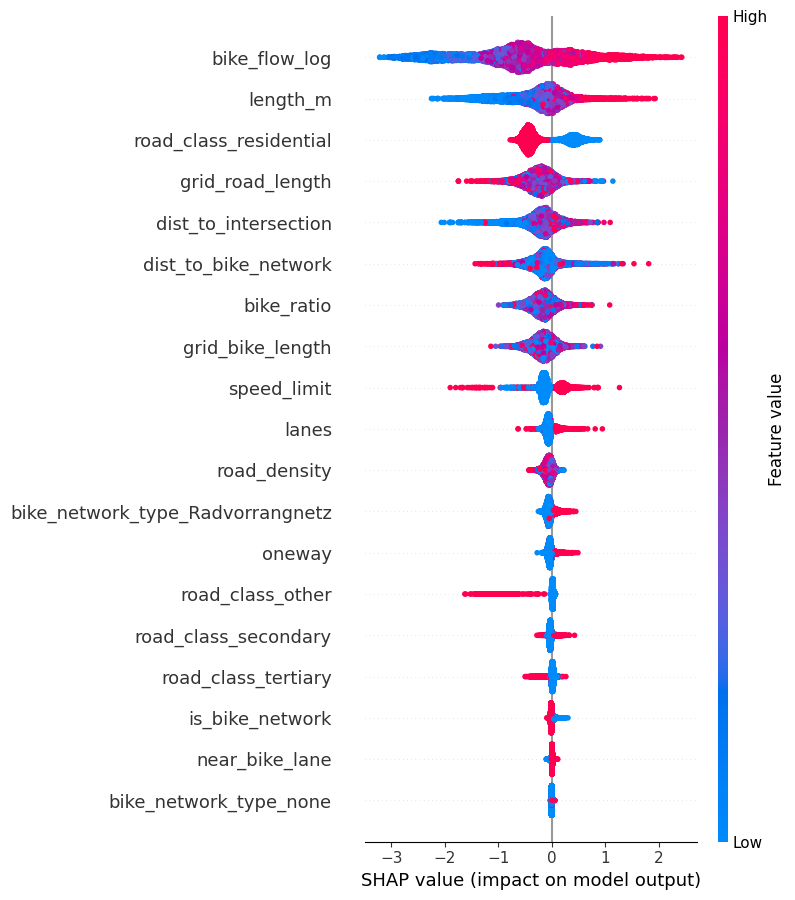

In [32]:
X_sample = X_test#.sample(2000, random_state=42)

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

In [118]:
edges["crash_probability"] = xgb.predict_proba(X)[:,1]

print("\nCRASH PROBABILITY DISTRIBUTION")
print(edges["crash_probability"].describe())


CRASH PROBABILITY DISTRIBUTION
count    60984.000000
mean         0.129389
std          0.205081
min          0.000028
25%          0.013228
50%          0.044931
75%          0.135961
max          0.979421
Name: crash_probability, dtype: float64


In [119]:
edges["expected_crashes"] = edges["crash_probability"] * edges["bike_flow"]

print("\nEXPECTED CRASHES (Exposure adjusted)")
print(edges["expected_crashes"].describe())


EXPECTED CRASHES (Exposure adjusted)
count    60984.000000
mean        83.689172
std        205.215868
min          0.000300
25%          1.123908
50%          9.798311
75%         59.284082
max       2774.566773
Name: expected_crashes, dtype: float64


In [120]:
edges[edges['crash']==0]['crash_probability'].mean(),edges[edges['crash']>0]['crash_probability'].mean()

(np.float32(0.088084), np.float32(0.69918627))

## Infrastructure scenario simulation

In [70]:
scenario1 = X.copy()

baseline_prob = np.average(
    edges["crash_probability"],
    weights=edges["bike_flow"]
)

threshold = edges["crash_probability"].quantile(0.9)
mask1 = edges["crash_probability"] >= threshold

scenario1.loc[mask1, "is_bike_network"] = 1
scenario1.loc[mask1, "near_bike_lane"] = 1
scenario1.loc[mask1, "dist_to_bike_network"] = 0

if "grid_bike_length" in scenario1.columns:
    scenario1.loc[mask1, "grid_bike_length"] = scenario1.loc[mask1, "grid_road_length"] * 0.5

if "bike_ratio" in scenario1.columns:
    scenario1.loc[mask1, "bike_ratio"] = 0.5

edges["prob_scenario1"] = xgb.predict_proba(scenario1)[:,1]

scenario1_prob = np.average(
    edges["prob_scenario1"],
    weights=edges["bike_flow"]
)

reduction1 = (baseline_prob - scenario1_prob) / baseline_prob * 100

print("\nScenario 1: High-Risk Roads")
print("Segments modified:", mask1.sum())
print("Baseline probability:", baseline_prob)
print("Scenario probability:", scenario1_prob)
print("Crash risk reduction (%):", reduction1)


Scenario 1: High-Risk Roads
Segments modified: 6100
Baseline probability: 0.22444516779938264
Scenario probability: 0.18260061177444398
Crash risk reduction (%): 18.64355398479368


In [38]:
threshold = edges["crash_probability"].quantile(0.9)
high_risk_edges = edges[edges["crash_probability"] >= threshold]
low_risk_edges = edges[edges["crash_probability"] < threshold]

In [39]:
crash_percent_high_risk = high_risk_edges["crash"].mean() * 100
crash_percent_low_risk = low_risk_edges["crash"].mean() * 100

print("Crash % in top 10% high risk streets:", round(crash_percent_high_risk,2))
print("Crash % in bottom 90% low risk streets:", round(crash_percent_low_risk,2))

Crash % in top 10% high risk streets: 60.79
Crash % in bottom 90% low risk streets: 0.75


In [40]:
# total crashes in the network
total_crashes = edges["crash_count"].sum()

# crashes occurring on top 10% high-risk streets
high_risk_crashes = high_risk_edges["crash_count"].sum()

# share of crashes
share_high_risk = (high_risk_crashes / total_crashes) * 100

print("Total crashes:", total_crashes)
print("Crashes in top 10% streets:", high_risk_crashes)
print("Share of crashes in top 10% streets:", round(share_high_risk,2), "%")

Total crashes: 5137.0
Crashes in top 10% streets: 4657.0
Share of crashes in top 10% streets: 90.66 %


## Infrastructure impact summary

In [23]:
edges["risk_difference"] = edges["crash_probability"] - edges["prob_scenario1"]

avg_reduction = edges["risk_difference"].mean()

weighted_reduction = np.average(
    edges["risk_difference"],
    weights=edges["bike_flow"]
)

print("\nINFRASTRUCTURE IMPACT SUMMARY")
print("Average risk reduction per segment:", avg_reduction)
print("Flow weighted risk reduction:", weighted_reduction)


INFRASTRUCTURE IMPACT SUMMARY
Average risk reduction per segment: 0.027030252
Flow weighted risk reduction: 0.041844556038351584


## EFFECT BY ROAD CLASS

In [24]:
def infra_effect(variable):
    
    table = edges.groupby([variable,"near_bike_lane"]).agg(
        risk=("crash_probability","mean"),
        segments=("crash_probability","count")
    ).reset_index()
    
    pivot = table.pivot(index=variable,columns="near_bike_lane",values="risk")
    
    pivot["risk_reduction_%"] = (pivot[0] - pivot[1]) / pivot[0] * 100
    
    return pivot

print("\nEFFECT BY ROAD CLASS")
print(infra_effect("road_class"))

print("\nEFFECT BY SPEED LIMIT")
print(infra_effect("speed_limit"))


EFFECT BY ROAD CLASS
near_bike_lane         0         1  risk_reduction_%
road_class                                          
major           0.202430  0.317103        -56.648087
other           0.037001  0.070295        -89.982170
residential     0.031583  0.116359       -268.419159
secondary       0.153780  0.264110        -71.746040
tertiary        0.105155  0.214528       -104.010216

EFFECT BY SPEED LIMIT
near_bike_lane         0         1  risk_reduction_%
speed_limit                                         
10.0            0.019925  0.084359       -323.379120
15.0            0.008476  0.026330       -210.662262
20.0            0.034606  0.137654       -297.772491
30.0            0.033891  0.129032       -280.729767
40.0            0.014792  0.136650       -823.839111
50.0            0.118721  0.228444        -92.420158
60.0            0.012692  0.137238       -981.335449
70.0            0.016927  0.190286      -1024.124390
80.0            0.003943  0.010934       -177.333969
1

##  Bike lane safety comparison

In [41]:
shap_df = pd.DataFrame(
    shap_values,
    columns=X_sample.columns
)

shap_df["is_bike_network"].mean()
shap_importance = shap_df.abs().mean().sort_values(ascending=False)

In [42]:
shap_importance

bike_flow_log                       0.914971
length_m                            0.436082
road_class_residential              0.425564
grid_road_length                    0.286261
dist_to_intersection                0.280364
dist_to_bike_network                0.230058
bike_ratio                          0.219517
grid_bike_length                    0.207115
speed_limit                         0.173257
lanes                               0.082066
road_density                        0.077132
bike_network_type_Radvorrangnetz    0.068329
oneway                              0.050906
road_class_other                    0.039096
road_class_secondary                0.037049
road_class_tertiary                 0.036244
is_bike_network                     0.024885
near_bike_lane                      0.013742
bike_network_type_none              0.002905
dtype: float32

In [43]:

lane_risk = edges.groupby("near_bike_lane").agg(
    mean_risk=("crash_probability","mean"),
    segments=("crash_probability","count")
)

print("\nBIKE LANE SAFETY COMPARISON")
print(lane_risk)



BIKE LANE SAFETY COMPARISON
                mean_risk  segments
near_bike_lane                     
0                0.044355     17787
1                0.164404     43197


##  Bike flow exposure effect

In [44]:


edges["flow_bin"] = pd.qcut(edges["bike_flow"], 5)

flow_risk = edges.groupby("flow_bin").agg(
    mean_risk=("crash_probability","mean"),
    segments=("crash_probability","count")
)

print("\nBICYCLE FLOW EFFECT")
print(flow_risk)


BICYCLE FLOW EFFECT
                   mean_risk  segments
flow_bin                              
(2.416, 42.468]     0.027942     12197
(42.468, 151.093]   0.086388     12197
(151.093, 302.66]   0.106889     12196
(302.66, 639.523]   0.153579     12197
(639.523, 3000.0]   0.272147     12197


## Distance to bike network

In [45]:
edges["dist_bin"] = pd.qcut(edges["dist_to_bike_network"], 5,duplicates="drop")

dist_risk = edges.groupby("dist_bin").agg(
    mean_risk=("crash_probability","mean"),
    segments=("crash_probability","count")
)

print("\nDISTANCE TO BIKE NETWORK EFFECT")
print(dist_risk)


DISTANCE TO BIKE NETWORK EFFECT
                  mean_risk  segments
dist_bin                             
(-0.001, 2.206]    0.156814     36590
(2.206, 93.71]     0.135852     12197
(93.71, 909.145]   0.040654     12197


##  Bike network density effect

In [ ]:
edges["ratio_bin"] = pd.qcut(edges["bike_ratio"], 5)

ratio_risk = edges.groupby("ratio_bin").agg(
    mean_risk=("crash_probability","mean"),
    segments=("crash_probability","count")
)

print("\nBIKE NETWORK DENSITY EFFECT")
print(ratio_risk)


BIKE NETWORK DENSITY EFFECT
                  mean_risk  segments
ratio_bin                            
(-0.001, 0.0614]   0.061958     12206
(0.0614, 0.165]    0.088570     12210
(0.165, 0.238]     0.129584     12177
(0.238, 0.333]     0.157054     12195
(0.333, 7.05]      0.209886     12196



## Road hierarchy risk

In [ ]:
road_risk = edges.groupby("road_class").agg(
    mean_risk=("crash_probability","mean"),
    segments=("crash_probability","count")
).sort_values("mean_risk")

print("\nCRASH RISK BY ROAD CLASS")
print(road_risk)


CRASH RISK BY ROAD CLASS
             mean_risk  segments
road_class                      
other         0.060721      1405
residential   0.085490     41810
tertiary      0.198530      7035
secondary     0.252253      8374
major         0.305928      2360


##  High risk segments

In [ ]:
threshold = edges["crash_probability"].quantile(0.9)

high_risk_edges = edges[edges["crash_probability"] >= threshold]

print("\nHIGH RISK SEGMENTS")
print("Risk threshold:", threshold)
print("Segments:", len(high_risk_edges))
print("Percent of network:", len(high_risk_edges)/len(edges)*100)


HIGH RISK SEGMENTS
Risk threshold: 0.3847968280315399
Segments: 6100
Percent of network: 10.002623638987275


In [42]:
edges["potential_safety_gain"] = edges["crash_probability"] - edges["prob_with_lane"]

priority = edges.sort_values("potential_safety_gain", ascending=False).head(20)

print("\nTOP SAFETY IMPROVEMENT SEGMENTS")
priority[[
    "road_class",
    "bike_flow",
    "crash_probability",
    "prob_with_lane",
    "potential_safety_gain"
]]


TOP SAFETY IMPROVEMENT SEGMENTS


,road_class,bike_flow,crash_probability,prob_with_lane,potential_safety_gain
41856,residential,24.461759,0.906877,0.008673,0.898204
41854,residential,24.461759,0.906877,0.008673,0.898204
1230,tertiary,206.202625,0.929607,0.034285,0.895321
46888,tertiary,206.202625,0.929607,0.034285,0.895321
2406,residential,49.544045,0.918615,0.025416,0.893199
3091,residential,49.544045,0.918615,0.025416,0.893199
7376,residential,43.661327,0.885284,0.003622,0.881662
53738,residential,43.661327,0.885284,0.003622,0.881662
46889,tertiary,204.399742,0.910686,0.038444,0.872241
1251,tertiary,204.399742,0.910686,0.038444,0.872241


In [ ]:
flow_risk = edges.groupby("flow_bin").agg(
    mean_risk=("crash_probability", "mean")
).reset_index()

flow_risk["flow_label"] = flow_risk["flow_bin"].apply(
    lambda x: f"{int(x.left)}–{int(x.right)}"
)

fig = px.line(
    flow_risk,
    x="flow_label",
    y="mean_risk",
    markers=True,
    labels={
        "flow_label": "Bicycle Traffic Volume",
        "mean_risk": "Crash Probability"
    },
    title="Crash Risk Increases with Bicycle Traffic Volume"
)

fig.update_traces(
    mode="lines+markers",
    line=dict(width=3, color="#2E7D32"),
    marker=dict(
        size=[8, 10, 12, 14, 18],  # increasing emphasis
        color=flow_risk["mean_risk"],
        colorscale="RdYlGn_r",
        showscale=True,
        colorbar=dict(title="Risk Level")
    )
)

fig.add_hrect(y0=0, y1=0.1, fillcolor="green", opacity=0.08, line_width=0)
fig.add_hrect(y0=0.1, y1=0.2, fillcolor="orange", opacity=0.08, line_width=0)
fig.add_hrect(y0=0.2, y1=0.35, fillcolor="red", opacity=0.08, line_width=0)

max_idx = flow_risk["mean_risk"].idxmax()
fig.add_annotation(
    x=flow_risk.loc[max_idx, "flow_label"],
    y=flow_risk.loc[max_idx, "mean_risk"],
    text="Highest risk",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    font=dict(size=14),
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=True, gridcolor="lightgray"),
    margin=dict(l=40, r=40, t=70, b=40)
)

fig.show()

In [ ]:
road_risk = (
    edges[edges['road_class'] != 'other']
    .groupby("road_class")
    .agg(mean_risk=("crash_probability", "mean"))
    .sort_values("mean_risk", ascending=True)
    .reset_index()
)

fig = px.bar(
    road_risk,
    x="mean_risk",
    y="road_class",
    orientation="h",
    labels={
        "road_class": "Road Class",
        "mean_risk": "Crash Probability"
    },
    title="Crash Risk by Road Class"
)

fig.update_traces(
    marker=dict(
        color=road_risk["mean_risk"],
        colorscale="RdYlGn_r",
        showscale=True,
        colorbar=dict(title="Risk Level")
    ),
    text=road_risk["mean_risk"].map(lambda x: f"{x:.3f}"),
    textposition="outside",
    cliponaxis=False
)

max_val = road_risk["mean_risk"].max()
fig.update_xaxes(range=[0, max_val * 1.25])  # adds 25% padding

# Risk zones
fig.add_vrect(x0=0, x1=0.1, fillcolor="green", opacity=0.06, line_width=0)
fig.add_vrect(x0=0.1, x1=0.2, fillcolor="orange", opacity=0.06, line_width=0)
fig.add_vrect(x0=0.2, x1=0.5, fillcolor="red", opacity=0.06, line_width=0)

# # Properly positioned annotation
# max_idx = road_risk["mean_risk"].idxmax()
# fig.add_annotation(
#     x=road_risk.loc[max_idx, "mean_risk"] * 1.07,  # push clearly outside
#     y=road_risk.loc[max_idx, "road_class"],
#     text="Highest risk",
#     # showarrow=True,
#     # arrowhead=2,
#     # ax=-60,
#     # ay=0
# )

# Layout
fig.update_layout(
    template="simple_white",
    title_x=0.5,
    font=dict(size=14),
    xaxis=dict(
        showgrid=True,
        gridcolor="lightgray",
        tickformat=".2f"
    ),
    yaxis=dict(showgrid=False),
    margin=dict(l=80, r=80, t=70, b=40)  # more right margin
)

fig.show()

In [102]:
edges[['geometry','prob_scenario1','crash_probability','bike_flow_log','crash','crash_count',
       'bike_flow','road_class','speed_limit','dist_to_intersection','oneway',
       'lanes','is_bike_network','bike_network_type','dist_to_bike_network']].to_crs(crs=4326).to_file('data/Processed/berlin_bicycle_safety_results.geojson', driver='GeoJSON')
